# Projeção para o Marco Legal do Saneamento 2033

metas da Lei 14.026/2020 (Marco Legal do Saneamento):
- **Água:** 99% de cobertura até 2033
- **Esgoto:** 90% de coleta até 2033


## 1. Carregamento dos dados


In [72]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

RENAME_COLS = {
    "Município": "nome_municipio",
    "Sigla UF": "sigla_uf",
    "Atendimento da população total com rede de abastecimento de água": "indice_atendimento_total_agua",
    "Atendimento da população urbana com rede coletora de esgoto": "indice_coleta_esgoto",
}

path = "../data/processed/snis_sinisa_merge_ibge_populacao.csv"
df = pd.read_csv(path, encoding="utf-8")
df.rename(columns=RENAME_COLS, inplace=True)
df["ano"] = df["ano"].astype(int)
df["id_municipio"] = df["id_municipio"].astype(str).str.strip()

ultimo_ano = df["ano"].max()
META_AGUA = 99.0
META_ESGOTO = 90.0
ANO_META = 2033

print(f"Período disponível: {df['ano'].min()} a {ultimo_ano}")
print(f"Municípios: {df['id_municipio'].nunique()}")
print(f"Linhas: {len(df)}")


Período disponível: 2014 a 2024
Municípios: 92
Linhas: 980


## 2. projeção linear ponderada (WLS)

A equação da reta é:

**valor = taxa * ano + intercepto**

Onde:
- **valor** = indicador em % (ex: cobertura de água)
- **taxa** = variação anual ponderada (pp/ano)
- **ano** = ano de referência
- **intercepto** = constante de ajuste da reta

Usamos **pesos exponenciais** com a fórmula:

`peso = exp(0.3 * (ano - ano_min))`

| Ano | Cálculo | Peso |
|-----|---------|------|
| 2014 | exp(0.3 * 0) = exp(0) | 1.0 |
| 2017 | exp(0.3 * 3) = exp(0.9) | 2.5 |
| 2020 | exp(0.3 * 6) = exp(1.8) | 6.0 |
| 2022 | exp(0.3 * 8) = exp(2.4) | 11.0 |
| 2024 | exp(0.3 * 10) = exp(3.0) | 20.1 |


## 3. Exemplo com um município


In [73]:
municipio_exemplo = "Piraí"
indicador = "indice_atendimento_total_agua"
meta = META_AGUA

g = df[(df["nome_municipio"] == municipio_exemplo) &
       df["ano"].between(2014, ultimo_ano)][["ano", indicador]].dropna()

print(f"Município: {municipio_exemplo}")
print(f"Dados disponíveis: {len(g)} anos ({g['ano'].min()}-{g['ano'].max()})\n")
print(g.to_string(index=False))


Município: Piraí
Dados disponíveis: 11 anos (2014-2024)

 ano  indice_atendimento_total_agua
2024                          97.88
2023                          80.16
2022                          89.94
2021                          79.18
2020                          77.70
2019                          79.18
2018                          77.47
2017                          91.40
2016                          95.86
2015                          99.50
2014                          99.17


In [ ]:
anos = g["ano"].values.astype(float)
pesos = np.exp(0.3 * (anos - anos.min()))
coef = np.polyfit(anos, g[indicador].values, 1, w=pesos)
taxa = coef[0]
intercepto = coef[1]

print(f"Pesos: de {pesos.min():.1f} (2014) a {pesos.max():.1f} ({int(anos.max())})")
print(f"Taxa de variação (ponderada): {taxa:.3f} pp/ano")
print(f"ponto de interseção: {intercepto:.2f}")
print(f"Equação da reta: y = {taxa:.3f} * ano + ({intercepto:.2f})")

# Valor atual estimado pela reta
atual = float(np.polyval(coef, ultimo_ano))
print(f"\nValor estimado atual ({ultimo_ano}): {atual:.1f}%")

# Projeção para 2033
proj = float(np.polyval(coef, ANO_META))
proj = min(max(proj, 0), 100)
print(f"Projeção para {ANO_META}: {proj:.1f}%")
print(f"Meta: {meta}%")
print(f"\nDiferença projeção vs meta: {proj - meta:.1f} pp")



Pesos: de 1.0 (2014) a 20.1 (2024)
Taxa de variação (ponderada): 3.113 pp/ano
ponto de interseção: -6207.62
Equação da reta: y = 3.113 * ano + (-6207.62)

Valor estimado atual (2024): 93.2%
Projeção para 2033: 100.0%
Meta: 99.0%

Diferença projeção vs meta: 1.0 pp


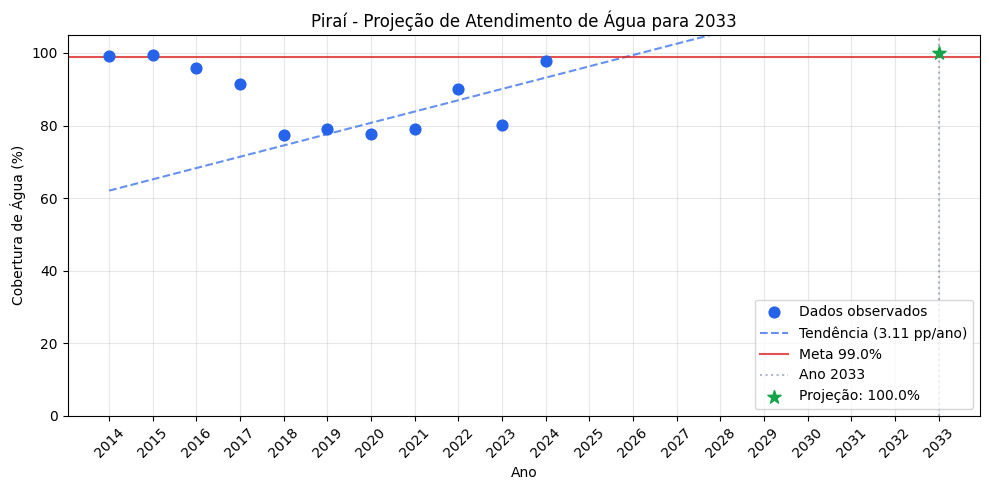

In [75]:
# Visualização do exemplo
fig, ax = plt.subplots(figsize=(10, 5))

# Dados históricos
ax.scatter(g["ano"], g[indicador], color="#2563eb", s=60, zorder=5, label="Dados observados")

# Reta de regressão + projeção
anos_range = np.arange(2014, 2034)
valores_reta = np.polyval(coef, anos_range)
ax.plot(anos_range, valores_reta, "--", color="#2563eb", alpha=0.7, label=f"Tendência ({taxa:.2f} pp/ano)")

# Meta e ano-alvo
ax.axhline(y=meta, color="#dc2626", linestyle="-", alpha=0.8, label=f"Meta {meta}%")
ax.axvline(x=ANO_META, color="#64748b", linestyle=":", alpha=0.5, label=f"Ano {ANO_META}")

# Ponto da projeção
ax.scatter([ANO_META], [proj], color="#16a34a", s=100, marker="*", zorder=6, label=f"Projeção: {proj:.1f}%")

ax.set_xlabel("Ano")
ax.set_ylabel(f"Cobertura de Água (%)")
ax.set_title(f"{municipio_exemplo} - Projeção de Atendimento de Água para 2033")
ax.legend(loc="lower right")
ax.set_ylim(0, 105)
ax.set_xticks(range(2014, 2034))
ax.tick_params(axis="x", rotation=45)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()



## 4. Classificação dos municípios

**Já atingiu**: Valor atual >= meta

**No prazo**: Taxa > 0 e projeção atinge meta antes de 2033

**Não atingirá**: Taxa > 0 mas projeção não atinge meta até 2033

**Em retrocesso**: Taxa <= 0 (indicador em queda)


In [76]:
def projetar_municipio(g, indicador, meta, ano_meta=2033):
    """Calcula projeção linear para um município."""
    if len(g) < 3:
        return None

    anos = g["ano"].values.astype(float)
    pesos = np.exp(0.3 * (anos - anos.min()))
    coef = np.polyfit(anos, g[indicador].values, 1, w=pesos)
    taxa = coef[0]
    atual = float(np.polyval(coef, ultimo_ano))
    proj = float(np.polyval(coef, ano_meta))
    proj = min(max(proj, 0), 100)

    if atual >= meta:
        status = "Já atingiu"
    elif taxa <= 0:
        status = "Em retrocesso"
    else:
        try:
            ano_p = int(np.ceil((meta - coef[1]) / coef[0]))
        except (ZeroDivisionError, OverflowError):
            ano_p = 9999
        status = "No prazo" if ano_p <= ano_meta else "Não atingirá"

    return {
        "taxa_pp_ano": round(taxa, 3),
        "atual_pct": round(atual, 1),
        "projecao_2033_pct": round(proj, 1),
        "status": status,
    }



## 5. Resultados - Água (meta 99%)


In [ ]:
indicador = "indice_atendimento_total_agua"
meta = META_AGUA

df_h = df[df["ano"].between(2014, ultimo_ano)][["ano", "id_municipio", "nome_municipio", indicador]].dropna()

resultados = []
for mid, g in df_h.groupby("id_municipio"):
    r = projetar_municipio(g, indicador, meta)
    if r:
        r["municipio"] = g["nome_municipio"].iloc[0]
        resultados.append(r)

df_agua = pd.DataFrame(resultados)
print(f"Municípios analisados (Água): {len(df_agua)}")
print(f"\nDistribuição por status:")
print(df_agua["status"].value_counts().to_string())


Municípios analisados (Água): 92

Distribuição por status:
status
No prazo         51
Já atingiu       16
Em retrocesso    13
Não atingirá     12


In [ ]:
for status in ["Já atingiu", "No prazo", "Não atingirá", "Em retrocesso"]:
    sub = df_agua[df_agua["status"] == status].sort_values("projecao_2033_pct")
    if sub.empty:
        continue
    print(f"\n{'='*60}")
    print(f"{status.upper()} ({len(sub)} municípios)")
    print(f"{'='*60}")
    print(sub[["municipio", "atual_pct", "taxa_pp_ano", "projecao_2033_pct"]].to_string(index=False))



JÁ ATINGIU (16 municípios)
                municipio  atual_pct  taxa_pp_ano  projecao_2033_pct
            Volta Redonda       99.5       -0.105               98.6
                 Araruama      100.0        1.003              100.0
Comendador Levy Gasparian       99.0        0.393              100.0
                    Areal       99.8        0.026              100.0
        Casimiro de Abreu      101.0        3.177              100.0
      Conceição de Macabu      100.9        4.840              100.0
                 Cordeiro       99.2        0.579              100.0
    Campos dos Goytacazes       99.9        0.769              100.0
                 Mesquita       99.8        0.104              100.0
                Nilópolis      100.1        0.142              100.0
              Nova Iguaçu      100.2        2.796              100.0
                  Niterói      100.0        0.000              100.0
                   Paraty      111.4        6.469              100.0
      

## 6. Resultados - Esgoto (meta 90%)


In [ ]:
indicador = "indice_coleta_esgoto"
meta = META_ESGOTO

df_h = df[df["ano"].between(2014, ultimo_ano)][["ano", "id_municipio", "nome_municipio", indicador]].dropna()

resultados = []
for mid, g in df_h.groupby("id_municipio"):
    r = projetar_municipio(g, indicador, meta)
    if r:
        r["municipio"] = g["nome_municipio"].iloc[0]
        resultados.append(r)

df_esgoto = pd.DataFrame(resultados)
print(f"Municípios analisados (Esgoto): {len(df_esgoto)}")
print(f"\nDistribuição por status:")
print(df_esgoto["status"].value_counts().to_string())


Municípios analisados (Esgoto): 84

Distribuição por status:
status
Em retrocesso    42
Já atingiu       23
No prazo         13
Não atingirá      6


In [ ]:
for status in ["Já atingiu", "No prazo", "Não atingirá", "Em retrocesso"]:
    sub = df_esgoto[df_esgoto["status"] == status].sort_values("projecao_2033_pct")
    if sub.empty:
        continue
    print(f"\n{'='*60}")
    print(f"{status.upper()} ({len(sub)} municípios)")
    print(f"{'='*60}")
    print(sub[["municipio", "atual_pct", "taxa_pp_ano", "projecao_2033_pct"]].to_string(index=False))



JÁ ATINGIU (23 municípios)
                  municipio  atual_pct  taxa_pp_ano  projecao_2033_pct
            Arraial do Cabo       90.2       -2.354               69.0
              Iguaba Grande       90.4       -2.091               71.6
                  Cabo Frio       90.1       -1.662               75.2
                    Niterói       95.7       -1.021               86.5
                     Italva       94.3       -0.108               93.4
              Nova Friburgo       93.5        0.315               96.3
                    Resende       97.8        0.034               98.1
  Comendador Levy Gasparian      100.3        0.426              100.0
      Campos dos Goytacazes       94.6        6.884              100.0
Engenheiro Paulo de Frontin      100.0        0.000              100.0
                  Itaperuna       99.2        7.490              100.0
             Laje do Muriaé       98.4        5.241              100.0
                 Natividade       96.5        6.6